In [1]:
import arviz as az
import arviz_plots as azp
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import statsmodels.api as sm

az.style.use('arviz-darkgrid')
plt.style.use('ggplot')

g++ not available, if using conda: `conda install gxx`


# Bayesian Linear Regression

So far, we have established the fundamentals of Bayesian Statistics and learned how to perform statistical inference. From now on, we will combine what we have learned in Bayesian Statistics with regression models.


## From PyMC to Bambi

In the previous notebooks, we built a variety of Bayesian models with `PyMC`. We can build Bayesian regression models with it as well. For example:

**Example**

$n = 100$

$X \sim \mathcal{N}(10,2^2)$

$\epsilon \sim \mathcal{N}(0,1^2)$

$y = 5X + \epsilon$

Let's say that we expect $y = 10$ when $X = 0$. We are also not sure about the true parameter values. In this case, we can use the following priors:

Priors:

$\beta_0 \sim C(10,5)$

$\beta_1 \sim Flat$

$\sigma \sim \text{HalfNormal}(5)$

The likelihood of $y$ is:

$y \mid X \sim \mathcal{N}(\mu,\sigma^2)$

where

$\mu = \beta_0 + \beta_1X$


In [2]:
np.random.seed(12)

n = 100
X = np.random.normal(10, 2, n)
e = np.random.normal(0, 1, n)
y = 5 * X + e

with pm.Model() as first_model:
    beta0 = pm.Cauchy("beta0", alpha = 10, beta=5)
    beta1 = pm.Flat("beta1")
    sigma = pm.HalfNormal("sigma", sigma=5)

    mu = beta0 + beta1 * X
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample()


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]


c:\Users\egemen.u.dalgic\NEW\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [3]:
results = az.summary(trace, ci_prob=0.95)
results

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,0.36,0.48,-0.59,1.3,1412,1729,1.00,0.013,0.0092
beta1,4.941,0.048,4.8,5,1422,1543,1.00,0.0013,0.00091
sigma,1.04,0.074,0.91,1.2,2027,2049,1.00,0.0016,0.0012


The model parameters are close to the values used to generate the dataset. Although `PyMC` can be used for regression modeling, we will use `Bambi` instead because of its convenience and syntax similarity to the `statsmodels` library. For example, the same model can be created like this:

In [4]:
priors = {"Intercept": bmb.Prior("Cauchy", alpha = 10, beta=5), 
          "X": bmb.Prior("Flat"), 
          "sigma": bmb.Prior("HalfNormal", sigma=5)}

dataframe = pd.DataFrame({"X": X, "y": y})
model = bmb.Model("y ~ X", priors=priors, data = dataframe)
print(model)
trace_bambi = model.fit()


Initializing NUTS using jitter+adapt_diag...


       Formula: y ~ X
        Family: gaussian
          Link: mu = identity
  Observations: 100
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Cauchy(alpha: 10.0, beta: 5.0)
            X ~ Flat()
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 5.0)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, X]


c:\Users\egemen.u.dalgic\NEW\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


In [5]:
results_bambi = az.summary(trace_bambi, ci_prob=0.95)
results_bambi


,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,1.041,0.075,0.91,1.2,5467,2923,1.00,0.001,0.00073
Intercept,0.33,0.485,-0.59,1.3,6108,3259,1.00,0.0062,0.0043
X,4.943,0.0489,4.8,5,6105,3286,1.00,0.00063,0.00043


The results are similar to the previous results. The small differences in parameter values are due to MCMC sampling variation, which is not important.

Now that we know how to create Bayesian regression models, we can move on to the next topic, which explains what Bayesian regression offers that a frequentist model cannot.


## From OLS to Bayesian Linear Model

Recall the OLS equation:

$\hat{y} = X\hat{\beta}$

where the least squares estimate of $\beta$ is

$\hat{\beta} = (X^TX)^{-1}X^Ty$

The analytical formula works well, but it assumes that the error $\epsilon$ follows a normal distribution:

$\epsilon \sim \mathcal{N}(0,\sigma^2)$

If there are anomalies in the dataset, the assumption is violated, and the coefficients will be distorted. Luckily, we can overcome this issue by using priors and alternative likelihood distributions in the Bayesian framework.

Let's see this in an example.

**Example**

$n = 100$

$X \sim \mathcal{N}(5,1^2)$

$\epsilon \sim \mathcal{N}(0,1^2)$

$y = 2X + \epsilon$


In [6]:
np.random.seed(42)
X = np.random.normal(loc = 5, scale = 1,size = 100)
error = np.random.normal(loc = 0, scale = 1,size = 100)
y = 2*X + error

model = sm.OLS(y,sm.add_constant(X)).fit()

prediction = model.get_prediction(sm.add_constant(X))
prediction_frame = prediction.summary_frame(alpha = 0.05)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     312.2
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           3.14e-32
Time:                        10:43:07   Log-Likelihood:                -135.71
No. Observations:                 100   AIC:                             275.4
Df Residuals:                      98   BIC:                             280.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7237      0.523      1.383      0.1

C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_10596\1320934452.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_10596\1320934452.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


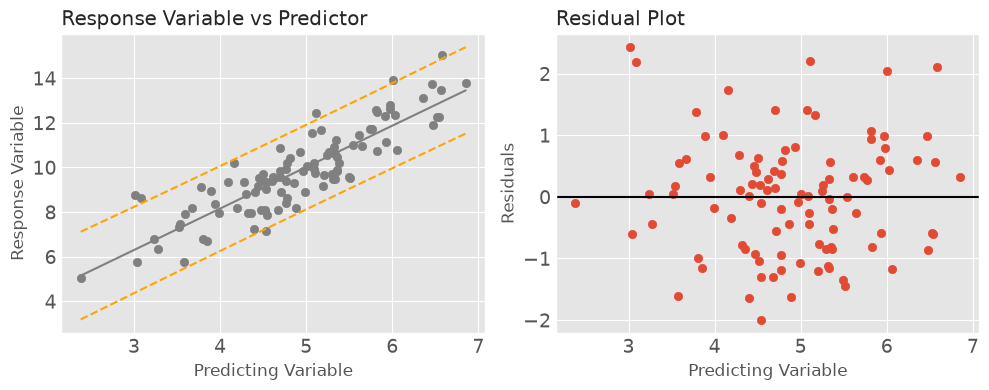

In [7]:
order = np.argsort(X)

fig,ax = plt.subplots(ncols = 2,figsize = (10,4))

ax[0].set_xlabel("Predicting Variable")
ax[0].set_ylabel("Response Variable")
ax[0].set_title("Response Variable vs Predictor",loc = 'left')
ax[0].plot(X[order], prediction_frame['mean'].iloc[order], color='grey')
ax[0].plot(X[order], prediction_frame['obs_ci_lower'].iloc[order], color = 'orange', linestyle = '--')
ax[0].plot(X[order], prediction_frame['obs_ci_upper'].iloc[order], color = 'orange', linestyle = '--')
ax[0].scatter(X, y,color='grey', label='Data')

ax[1].scatter(X, model.resid)
ax[1].axhline(y = 0, color = "black")
ax[1].set_xlabel("Predicting Variable")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residual Plot",loc = 'left')

fig.tight_layout()
fig.show()


Since there are no anomalies in the dataset, the model fits the data well. Now, let's see how a Bayesian regression model performs on the same data. We will again use weakly informative or noninformative priors.

Priors:

$\beta_0 \sim C(0,5)$

$\beta_1 \sim \text{Flat}$

$\sigma \sim \text{HalfNormal}(5)$

Likelihood:

$y \mid X \sim \mathcal{N}(\mu,\sigma^2)$

where

$\mu = \beta_0 + \beta_1X$

In [8]:
priors = {"Intercept": bmb.Prior("Cauchy", alpha = 0, beta = 5),
          "X": bmb.Prior("Flat"), 
          "sigma": bmb.Prior("HalfNormal", sigma=5)}

dataframe = pd.DataFrame({"X": X, "y": y})
model = bmb.Model("y ~ X", priors=priors, data = dataframe)
trace = model.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, X]


c:\Users\egemen.u.dalgic\NEW\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


In [9]:
results = az.summary(trace, ci_prob=0.95)
results

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,0.961,0.07,0.84,1.1,5584,3211,1.00,0.00095,0.00067
Intercept,0.73,0.517,-0.3,1.8,6167,3199,1.00,0.0066,0.0047
X,1.855,0.104,1.6,2.1,6257,3226,1.00,0.0013,0.00096


The results are again similar. Considering the priors we use and the fact that we are trying to predict a single variable using 100 observations, this is not surprising. In the next example, we will see how they differ when the conditions are not ideal.

**Example**

$n = 100$

$X_{\text{normal}} \sim \mathcal{N}(5,1^2)$

$X_{\text{outlier}} = \{15,16,17\}$

$X = [X_{\text{normal}},X_{\text{outlier}}]$

$\epsilon \sim \mathcal{N}(0,1^2)$

$y_{\text{normal}} = 2X + \epsilon$

$y_{\text{outlier}} = 4X_{\text{outlier}} + 20$

$y = [y_{\text{normal}},y_{\text{outlier}}]$


In [10]:
np.random.seed(42)
X = np.random.normal(loc = 5, scale = 1,size = 100)
error = np.random.normal(loc = 0, scale = 1,size = 100)
y = 2*X + error

outlier_X = np.array([15,16,17])
outlier_y = outlier_X *4 + 20

X = np.concatenate((X,outlier_X))
y = np.concatenate((y,outlier_y))

df = pd.DataFrame({"Independent_Variable":X,"Response_Variable":y})
model = sm.OLS(y,sm.add_constant(X)).fit()

prediction = model.get_prediction(sm.add_constant(X))
prediction_frame = prediction.summary_frame(alpha = 0.05)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     909.1
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.63e-52
Time:                        10:43:19   Log-Likelihood:                -288.78
No. Observations:                 103   AIC:                             581.6
Df Residuals:                     101   BIC:                             586.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.1899      1.077    -16.897      0.0

C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_10596\3947325433.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_10596\3947325433.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


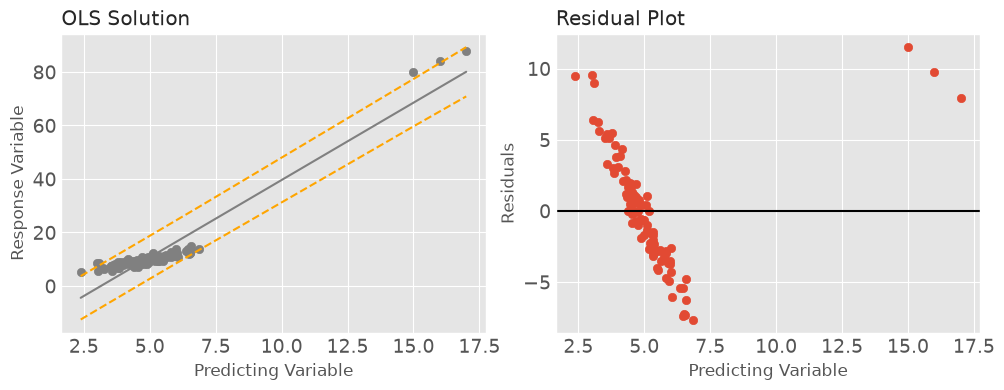

In [11]:
order = np.argsort(X)

fig,ax = plt.subplots(ncols = 2,figsize = (10,4))

ax[0].set_xlabel("Predicting Variable")
ax[0].set_ylabel("Response Variable")
ax[0].set_title("OLS Solution",loc = 'left')
ax[0].plot(X[order], prediction_frame['mean'].iloc[order], color='grey')
ax[0].plot(X[order], prediction_frame['obs_ci_lower'].iloc[order], color = 'orange', linestyle = '--')
ax[0].plot(X[order], prediction_frame['obs_ci_upper'].iloc[order], color = 'orange', linestyle = '--')
ax[0].scatter(X, y,color='grey', label='Data')

ax[1].scatter(X, model.resid)
ax[1].axhline(y = 0, color = "black")
ax[1].set_xlabel("Predicting Variable")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residual Plot",loc = 'left')

fig.tight_layout()
fig.show()

Notice how the model parameters differ from the parameters we used to generate the dataset. This example also shows that trusting $R^2$ can be misleading. The model claims that it can explain 90% of the variance in the data, but the prediction intervals and residual plots above clearly show that the model is vulnerable to these data points.


We can overcome this problem by detecting and eliminating the outliers in the first place. Alternatively, we can use regularized linear models, such as the ones we saw in the "Regularized Linear Models" notebook. Since this notebook shows the use cases of Bayesian regression, we will build a Bayesian model to obtain more appropriate results.

To make a robust model, we will use a Student $t$ distribution in the likelihood term. Again, we will use weakly informative or noninformative priors.

Priors:

$\beta_0 \sim \mathcal{N}(0,5^2)$

$\beta_1 \sim \text{Flat}$

$\sigma \sim \text{HalfCauchy}(0,3)$

$\nu \sim \text{Exponential}(\lambda = 1)$

Likelihood:

$y \mid X \sim \text{StudentT}(\mu,\sigma,\nu)$

where

$\mu = \beta_0 + \beta_1X$


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, nu, Intercept, Independent_Variable]


c:\Users\egemen.u.dalgic\NEW\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


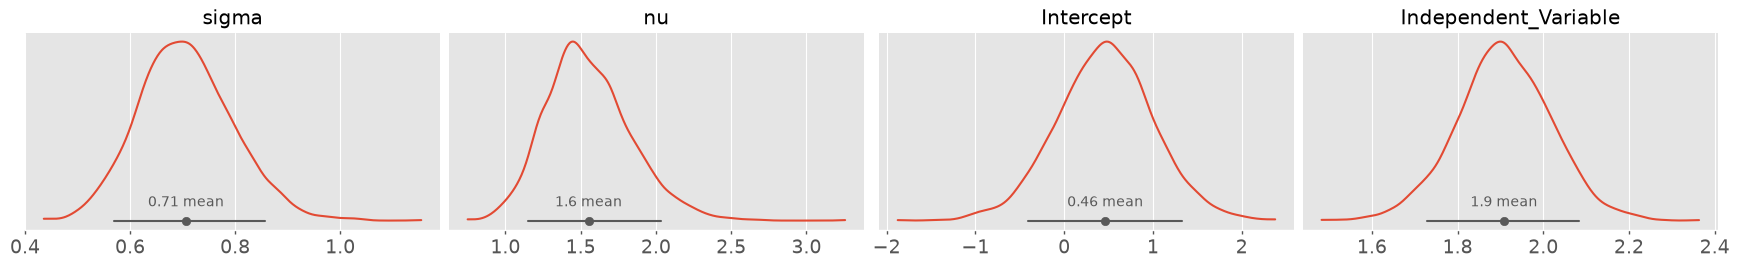

In [12]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=5),
    "Independent_Variable": bmb.Prior("Flat"),
    "sigma": bmb.Prior("HalfCauchy", beta=3),
    "nu": bmb.Prior("Exponential", lam=1)
}

t_bayes_model = bmb.Model("Response_Variable ~ Independent_Variable",
                          data=df,
                          family="t",
                          priors=priors)

t_inference = t_bayes_model.fit()
azp.plot_dist(t_inference)


In [13]:
az.summary(t_inference, ci_kind = "hdi", ci_prob = 0.95)

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,0.706,0.09,0.54,0.89,3412,2550,1.00,0.0015,0.0011
nu,1.552,0.282,1.1,2.2,3444,3434,1.00,0.0048,0.0039
Intercept,0.46,0.54,-0.61,1.5,4164,2607,1.00,0.0084,0.0063
Independent_Variable,1.908,0.111,1.7,2.1,3476,2996,1.00,0.0019,0.0014


Notice that the parameter $\beta_1 \approx 1.9$, which is close to the value (2) we used to generate the dataset. This is a substantial improvement compared to the OLS model, which found $\beta_1 \approx 5.8$. Also, the 95% HDI interval does not contain 0, therefore we have a strong tendency to believe that the coefficient of the independent variable is different from 0.

Similarly, the intercept $\beta_0$ in the Bayesian model is much closer to the ground truth than the intercept in the OLS model. But why is that the case? Although we did not use informative priors, the model performed much better.

In the Bayesian model, we used a Student $t$ distribution and allowed the degrees of freedom parameter $\nu$ and the scale parameter $\sigma$ to be determined by the data. Conversely, the other model uses a normal distribution, which penalizes deviations from the conditional mean quadratically:

$L = \frac 1 n \Sigma(y_i-\hat{y}_i)^2 \quad \text{(frequentist view)}$

The same applies in the Bayesian framework, where the log likelihood decreases quadratically with the deviation from the conditional mean:

$\log p(y_i \mid \mu_i) \propto -\frac{(y_i-\mu_i)^2}{2\sigma^2} \quad \text{(Bayesian view)}$

In both views, the penalty grows without bound, so a single distant point can pull the whole line towards itself.

From the summary table, we can see that $\nu \approx 1.5$. Therefore, the model treats $y$ as though it almost came from a Cauchy distribution. This decreases the contribution of the outlier terms significantly, so we obtain much more accurate results.


C:\Users\egemen.u.dalgic\AppData\Local\Temp\ipykernel_10596\2386859234.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


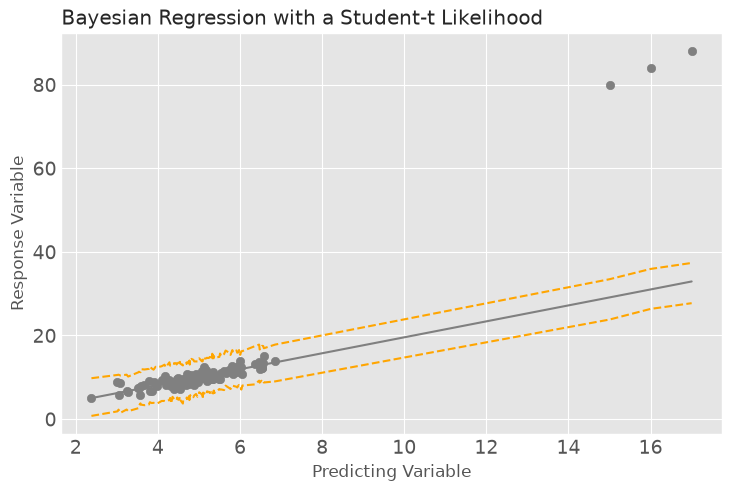

In [14]:
t_bayes_model.predict(t_inference, kind = "response")

order = np.argsort(X)
mean_prediction = t_inference.posterior["mu"].mean(dim = ["chain","draw"]).values
prediction_interval = az.hdi(t_inference.posterior_predictive,
                             group = "posterior_predictive",
                             prob = 0.95)["Response_Variable"].values

fig,ax = plt.subplots()
ax.scatter(X, y, color = 'grey', label = 'Data')
ax.plot(X[order], mean_prediction[order], color = 'grey')
ax.plot(X[order], prediction_interval[order,0], color = 'orange', linestyle = '--')
ax.plot(X[order], prediction_interval[order,1], color = 'orange', linestyle = '--')
ax.set_xlabel('Predicting Variable')
ax.set_ylabel('Response Variable')
ax.set_title("Bayesian Regression with a Student-t Likelihood", loc="left")
fig.show()


## Posterior Predictive Check

Posterior Predictive Check (PPC) is a useful way to evaluate model fit. It is a three step process:

1. The model parameters $\theta$ are estimated based on the data we have.
2. New data are generated using $\theta$.
3. The distribution of the newly generated data is compared with the distribution of the training data.

So, it basically checks the model's ability to generate data similar to the training data. Note that PPC is not a way to measure model success. It is a way to evaluate model fit.

Let's return to the last example and fit two models:

1. The first assumes that the likelihood of $y$ is normal.
2. The second assumes that the likelihood of $y$ follows a Student $t$ distribution.

Since we have already fitted a model with a Student $t$ distribution, we will only fit the first model before the PPC. For a fair comparison, we will use the same priors.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Independent_Variable]


c:\Users\egemen.u.dalgic\NEW\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


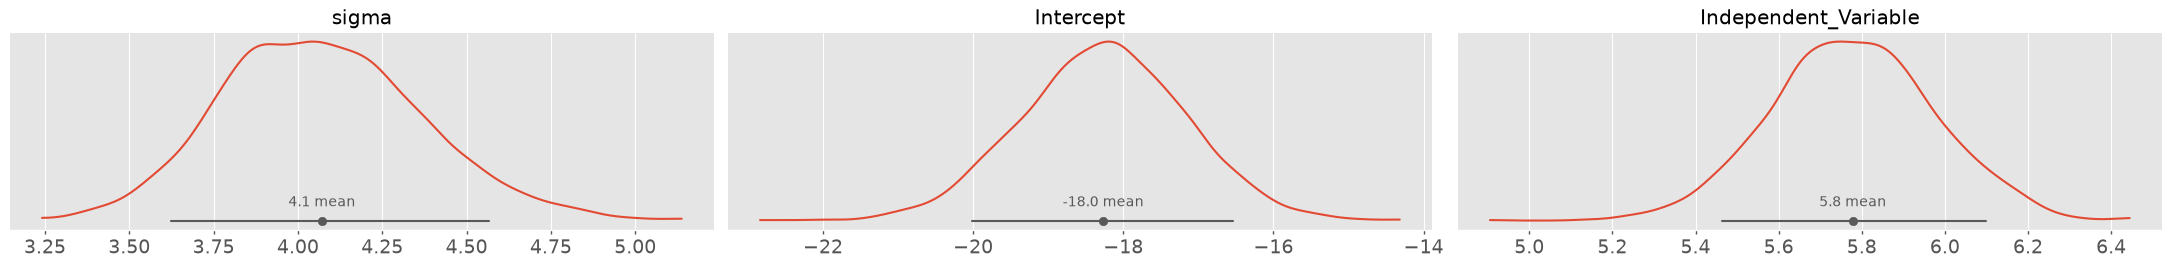

In [15]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=5),
    "Independent_Variable": bmb.Prior("Flat"),
    "sigma": bmb.Prior("HalfCauchy", beta=3)
}

normal_bayes_model = bmb.Model("Response_Variable ~ Independent_Variable",
                                data=df,
                                priors=priors)

normal_inference = normal_bayes_model.fit()
azp.plot_dist(normal_inference)

In [16]:
az.summary(normal_inference, ci_kind = "hdi", ci_prob = 0.95)

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,4.071,0.295,3.5,4.7,6039,3247,1.00,0.0038,0.0027
Intercept,-18.27,1.1,-20,-16,5556,3127,1.00,0.015,0.011
Independent_Variable,5.778,0.197,5.4,6.2,5694,3101,1.00,0.0026,0.0019


Since we know the true parameters, we can already see that the normal model did not fit well. However, in real life, we do not know the true parameters, so we use PPC.

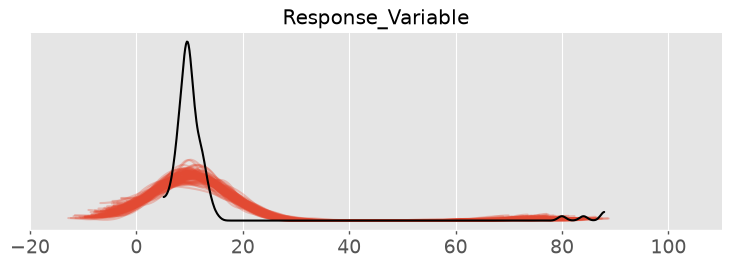

In [17]:
normal_bayes_model.predict(normal_inference, kind = "response")
normal_ppc = azp.plot_ppc_dist(normal_inference, num_samples = 100)
normal_ppc.viz["plot"]["Response_Variable"].item().set_xlim(-20, 110)
normal_ppc

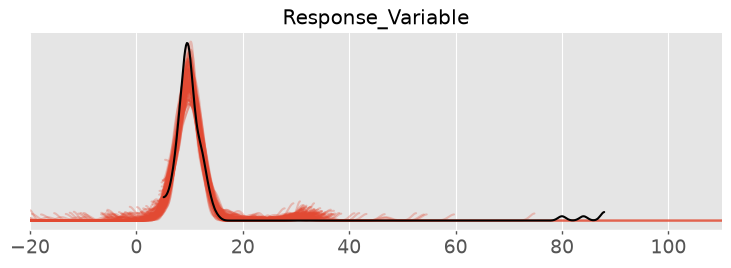

In [18]:
t_ppc = azp.plot_ppc_dist(t_inference, num_samples = 100)
t_ppc.viz["plot"]["Response_Variable"].item().set_xlim(-20, 110)
t_ppc

So, it is clear that the Bayesian model with a Student $t$ likelihood fits the training data better.